# Formula 1 Data Science Project
## Using FastF1 API — PCA, Clustering, and ARM Analysis

This notebook covers:
- **PCA TAB**: Dimensionality reduction on F1 telemetry/lap data
- **Clustering TAB**: KMeans, Hierarchical, and DBSCAN clustering
- **ARM TAB**: Association Rule Mining on race strategies

In [ ]:
# Install required libraries
!pip install fastf1 scikit-learn matplotlib seaborn plotly scipy mlxtend networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00


In [46]:
print("DDDD")
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

# Hierarchical
from scipy.cluster.hierarchy import dendrogram, linkage

# ARM
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Enable FastF1 cache
# fastf1.Cache.enable_cache('f1_cache')


DDDD


---
##  Data Collection via FastF1 API

In [45]:
# Load multiple race sessions for richer data
# We'll use the 2023 season — a great year with close competition

races_to_load = [
    (2023, 'Bahrain Grand Prix', 'R'),
    (2023, 'Saudi Arabian Grand Prix', 'R'),
    (2023, 'Australian Grand Prix', 'R'),
    (2023, 'Monaco Grand Prix', 'R'),
    (2023, 'British Grand Prix', 'R'),
    (2023, 'Italian Grand Prix', 'R'),
]

all_laps = []

for year, gp, session_type in races_to_load:
    try:
        session = fastf1.get_session(year, gp, session_type)
        session.load(telemetry=False, weather=True, messages=False)
        laps = session.laps.copy()
        laps['Race'] = gp
        laps['Year'] = year
        all_laps.append(laps)
        print(f' Loaded: {gp} {year}')
    except Exception as e:
        print(f' Could not load {gp} {year}: {e}')

laps_raw = pd.concat(all_laps, ignore_index=True)
print(f'\ Total laps collected: {len(laps_raw)}')
print(f'Columns: {list(laps_raw.columns)}')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

 Loaded: Bahrain Grand Prix 2023


req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11',

 Loaded: Saudi Arabian Grand Prix 2023


DEBUG:fastf1.ergast:Failed to parse timestamp '-1:24:05.036' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:24:06.409' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:24:07.342' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:24:07.559' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:01:16.239' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timi

...

 Loaded: Monaco Grand Prix 2023


DEBUG:fastf1.ergast:Failed to parse timestamp '-1:52:18.651' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '81', '63', '11', '14

 Loaded: British Grand Prix 2023


req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.8

 Loaded: Italian Grand Prix 2023
\ Total laps collected: 6446
Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'Race', 'Year']


In [ ]:
# Preview raw data
laps_raw.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Race,Year
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,0 days 01:02:36.652000,NaT,12,1.0,None,,False,False,Bahrain Grand Prix,2023
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,0 days 01:04:15.902000,NaT,12,1.0,None,,False,True,Bahrain Grand Prix,2023
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,0 days 01:05:53.876000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,0 days 01:07:31.882000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,0 days 01:09:09.858000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
5,0 days 01:12:25.879000,VER,1,0 days 00:01:37.986000,6.0,1.0,NaT,NaT,0 days 00:00:31.341000,0 days 00:00:42.632000,...,0 days 01:10:47.893000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
6,0 days 01:14:03.900000,VER,1,0 days 00:01:38.021000,7.0,1.0,NaT,NaT,0 days 00:00:31.290000,0 days 00:00:42.763000,...,0 days 01:12:25.879000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
7,0 days 01:15:42.054000,VER,1,0 days 00:01:38.154000,8.0,1.0,NaT,NaT,0 days 00:00:31.291000,0 days 00:00:42.833000,...,0 days 01:14:03.900000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
8,0 days 01:17:20.332000,VER,1,0 days 00:01:38.278000,9.0,1.0,NaT,NaT,0 days 00:00:31.336000,0 days 00:00:42.823000,...,0 days 01:15:42.054000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023
9,0 days 01:18:58.701000,VER,1,0 days 00:01:38.369000,10.0,1.0,NaT,NaT,0 days 00:00:31.361000,0 days 00:00:42.884000,...,0 days 01:17:20.332000,NaT,1,1.0,None,,False,True,Bahrain Grand Prix,2023


In [44]:
# Save raw data
laps_raw.to_csv('f1_laps_raw.csv', index=False)
print('Raw data saved to f1_laps_raw.csv')
laps_raw.shape

Raw data saved to f1_laps_raw.csv


(6446, 33)

---
#  PCA TAB

## What is PCA?

**Principal Component Analysis (PCA)** is an unsupervised dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional space while retaining as much variance (information) as possible. PCA works by identifying the directions (principal components) along which the data varies the most — these are the eigenvectors of the covariance matrix, and the corresponding eigenvalues indicate how much variance each component captures. By projecting data onto the top k principal components, we can visualize complex datasets in 2D or 3D, remove noise, speed up downstream algorithms, and understand which original features drive the most variation in the data.

## Data Preparation for PCA

In [ ]:
# Select quantitative lap features for PCA
# Remove qualitative columns and labels

def convert_laptime(t):
    """Convert timedelta to seconds (float)"""
    try:
        return t.total_seconds()
    except:
        return np.nan

laps_pca = laps_raw.copy()

# Convert time columns to seconds
time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
             'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
             'LapStartTime', 'Time']

for col in time_cols:
    if col in laps_pca.columns:
        laps_pca[col + '_sec'] = laps_pca[col].apply(convert_laptime)

# Select only numeric features relevant to performance
pca_features = [
    'LapTime_sec', 'Sector1Time_sec', 'Sector2Time_sec', 'Sector3Time_sec',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'LapNumber'
]

# Save the Driver label separately before removing
driver_labels = laps_pca['Driver'].copy()
team_labels = laps_pca['Team'].copy()
compound_labels = laps_pca['Compound'].copy()

# Keep only feature columns
laps_pca_clean = laps_pca[pca_features].copy()

# Drop rows with missing values
laps_pca_clean = laps_pca_clean.dropna()
driver_labels = driver_labels[laps_pca_clean.index]
team_labels = team_labels[laps_pca_clean.index]
compound_labels = compound_labels[laps_pca_clean.index]

print(f'Shape before cleaning: {laps_pca[pca_features].shape}')
print(f'Shape after cleaning: {laps_pca_clean.shape}')
laps_pca_clean.head()

Shape before cleaning: (6446, 9)
Shape after cleaning: (6017, 9)


,LapTime_sec,Sector1Time_sec,Sector2Time_sec,Sector3Time_sec,SpeedI1,SpeedI2,SpeedFL,SpeedST,LapNumber
1,97.974,31.342,42.504,24.128,227.0,238.0,278.0,288.0,2.0
2,98.006,31.388,42.469,24.149,227.0,238.0,278.0,287.0,3.0
3,97.976,31.271,42.642,24.063,228.0,238.0,278.0,289.0,4.0
4,98.035,31.244,42.724,24.067,228.0,239.0,278.0,290.0,5.0
5,97.986,31.341,42.632,24.013,229.0,239.0,279.0,291.0,6.0


In [43]:
# Save cleaned PCA data
laps_pca_clean.to_csv('f1_pca_data_clean.csv', index=False)
print(' Clean PCA data saved to f1_pca_data_clean.csv')
laps_pca_clean.describe()

 Clean PCA data saved to f1_pca_data_clean.csv


,LapTime_sec,Sector1Time_sec,Sector2Time_sec,Sector3Time_sec,SpeedI1,SpeedI2,SpeedFL,SpeedST,LapNumber
count,6017.000000,6017.000000,6017.000000,6017.000000,6017.000000,6017.000000,6017.000000,6017.000000,6017.000000
mean,91.623227,29.529516,34.496345,27.597366,250.758850,253.397042,275.395047,293.873691,29.857238
std,11.348458,6.427089,8.620579,5.568724,54.277286,56.591620,28.612181,29.504626,17.707003
min,75.650000,19.730000,17.589000,20.059000,92.000000,79.000000,59.000000,85.000000,2.000000
25%,83.374000,28.037000,29.848000,23.973000,204.000000,192.000000,256.000000,281.000000,15.000000
50%,92.320000,29.177000,36.745000,26.093000,273.000000,256.000000,281.000000,299.000000,29.000000
75%,96.919000,31.434000,41.910000,29.946000,291.000000,303.000000,294.000000,311.000000,43.000000
max,149.507000,72.748000,81.925000,56.352000,333.000000,342.000000,322.000000,359.000000,78.000000


## Normalize Using StandardScaler

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(laps_pca_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

print(' Data normalized (mean≈0, std≈1)')
print(X_scaled_df.describe().round(3))

 Data normalized (mean≈0, std≈1)
       LapTime_sec  Sector1Time_sec  Sector2Time_sec  Sector3Time_sec  \
count     6017.000         6017.000         6017.000         6017.000   
mean        -0.000            0.000            0.000            0.000   
std          1.000            1.000            1.000            1.000   
min         -1.408           -1.525           -1.961           -1.354   
25%         -0.727           -0.232           -0.539           -0.651   
50%          0.061           -0.055            0.261           -0.270   
75%          0.467            0.296            0.860            0.422   
max          5.101            6.725            5.502            5.164   

        SpeedI1   SpeedI2   SpeedFL   SpeedST  LapNumber  
count  6017.000  6017.000  6017.000  6017.000   6017.000  
mean     -0.000     0.000    -0.000    -0.000     -0.000  
std       1.000     1.000     1.000     1.000      1.000  
min      -2.925    -3.082    -7.564    -7.080     -1.573  
25%      -0.86

## PCA with n_components = 2

In [41]:
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

explained_2d = pca_2d.explained_variance_ratio_
cumulative_2d = np.cumsum(explained_2d)

print(' PCA 2D Results:')
print(f'  PC1 variance explained: {explained_2d[0]*100:.2f}%')
print(f'  PC2 variance explained: {explained_2d[1]*100:.2f}%')
print(f'  Cumulative (total retained): {cumulative_2d[-1]*100:.2f}%')

 PCA 2D Results:
  PC1 variance explained: 41.81%
  PC2 variance explained: 25.90%
  Cumulative (total retained): 67.71%


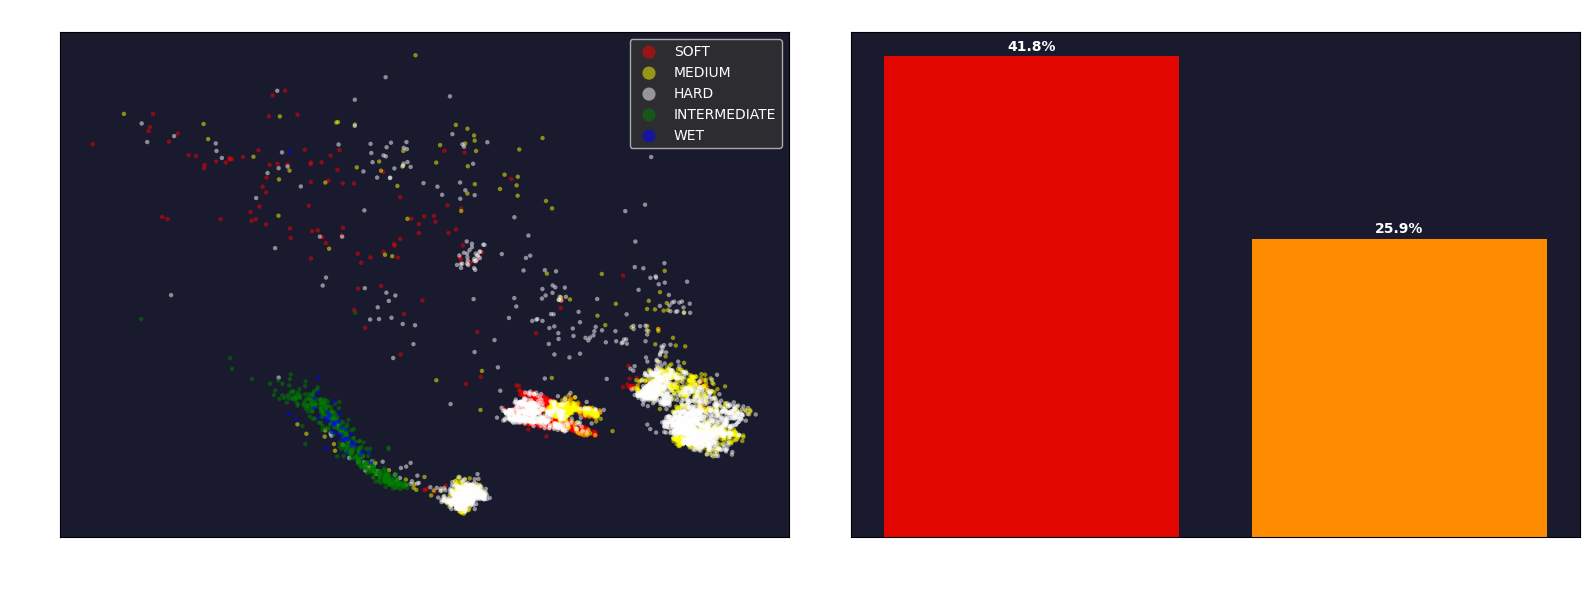

 2D PCA: 67.71% of information retained


In [40]:
# 2D PCA Visualization colored by Compound (tyre)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white',
                   'INTERMEDIATE': 'green', 'WET': 'blue'}

compounds = compound_labels.values
unique_compounds = [c for c in ['SOFT','MEDIUM','HARD','INTERMEDIATE','WET']
                    if c in compounds]

ax = axes[0]
ax.set_facecolor('#1a1a2e')
for comp in unique_compounds:
    mask = compounds == comp
    color = compound_colors.get(comp, 'gray')
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               label=comp, alpha=0.5, s=10,
               color=color, edgecolors='none')
ax.set_xlabel(f'PC1 ({explained_2d[0]*100:.1f}%)', color='white')
ax.set_ylabel(f'PC2 ({explained_2d[1]*100:.1f}%)', color='white')
ax.set_title('PCA 2D — Colored by Tyre Compound', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#333', labelcolor='white', markerscale=3)

# Scree-style bar chart
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
bars = ax2.bar(['PC1', 'PC2'], explained_2d * 100, color=['#e10600', '#ff8c00'])
ax2.set_ylabel('Variance Explained (%)', color='white')
ax2.set_title('Variance per Component (2D PCA)', color='white')
ax2.tick_params(colors='white')
for bar, val in zip(bars, explained_2d):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_2d_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print(f' 2D PCA: {cumulative_2d[-1]*100:.2f}% of information retained')

## PCA with n_components = 3

In [39]:
pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)

explained_3d = pca_3d.explained_variance_ratio_
cumulative_3d = np.cumsum(explained_3d)

print(' PCA 3D Results:')
for i, (var, cum) in enumerate(zip(explained_3d, cumulative_3d)):
    print(f'  PC{i+1}: {var*100:.2f}%  (cumulative: {cum*100:.2f}%)')
print(f'\n  Total retained: {cumulative_3d[-1]*100:.2f}%')

 PCA 3D Results:
  PC1: 41.81%  (cumulative: 41.81%)
  PC2: 25.90%  (cumulative: 67.71%)
  PC3: 11.65%  (cumulative: 79.36%)

  Total retained: 79.36%


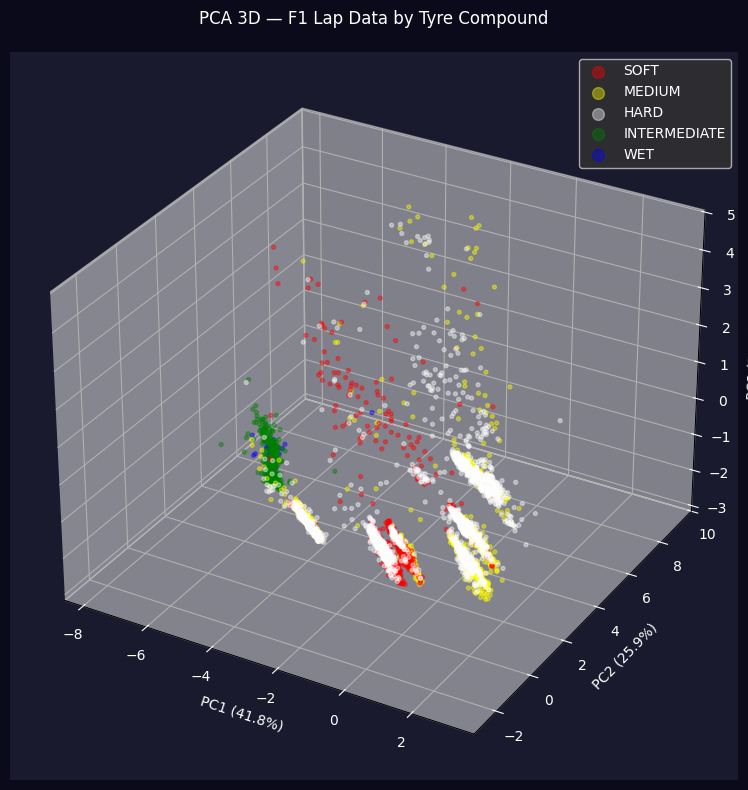

 3D PCA: 79.36% of information retained


In [38]:
# 3D PCA Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0a0a1a')

for comp in unique_compounds:
    mask = compounds == comp
    color = compound_colors.get(comp, 'gray')
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               label=comp, alpha=0.4, s=8, color=color)

ax.set_xlabel(f'PC1 ({explained_3d[0]*100:.1f}%)', color='white')
ax.set_ylabel(f'PC2 ({explained_3d[1]*100:.1f}%)', color='white')
ax.set_zlabel(f'PC3 ({explained_3d[2]*100:.1f}%)', color='white')
ax.set_title('PCA 3D — F1 Lap Data by Tyre Compound', color='white', pad=20)
ax.tick_params(colors='white')
ax.legend(facecolor='#333', labelcolor='white', markerscale=3)

plt.tight_layout()
plt.savefig('pca_3d_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print(f' 3D PCA: {cumulative_3d[-1]*100:.2f}% of information retained')

## How Many Dimensions for ≥95% Variance?

 Cumulative Variance by Component:
  1 components: 41.81%
  2 components: 67.71%
  3 components: 79.36%
  4 components: 89.27%
  5 components: 95.15%
  6 components: 97.81%
  7 components: 99.33%
  8 components: 100.00%
  9 components: 100.00%

 Components needed for ≥95% variance: 5


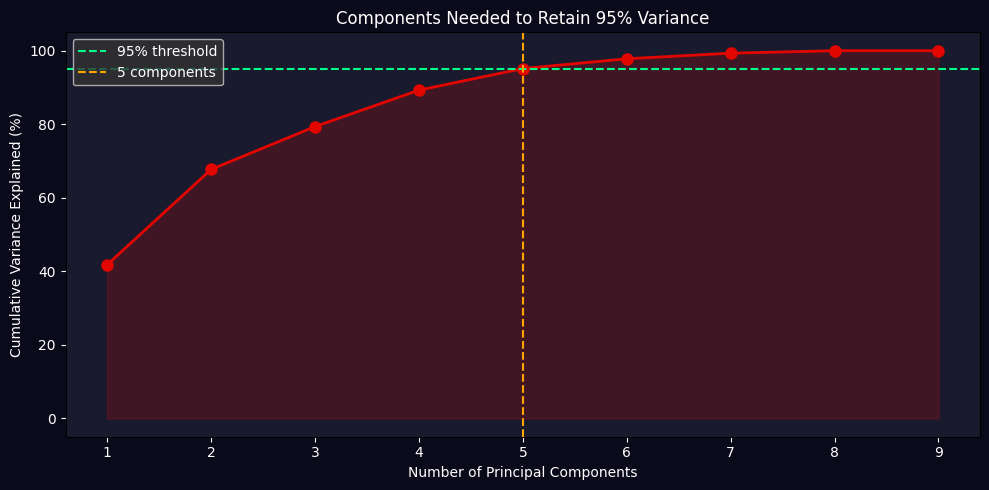

In [37]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f' Cumulative Variance by Component:')
for i, cum in enumerate(cumulative_var):
    print(f'  {i+1} components: {cum*100:.2f}%')

print(f'\n Components needed for ≥95% variance: {n_components_95}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0a0a1a')

ax.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
        'o-', color='#e10600', linewidth=2, markersize=8)
ax.axhline(y=95, color='#00ff88', linestyle='--', label='95% threshold')
ax.axvline(x=n_components_95, color='orange', linestyle='--',
           label=f'{n_components_95} components')
ax.fill_between(range(1, len(cumulative_var)+1), cumulative_var*100,
                alpha=0.2, color='#e10600')

ax.set_xlabel('Number of Principal Components', color='white')
ax.set_ylabel('Cumulative Variance Explained (%)', color='white')
ax.set_title('Components Needed to Retain 95% Variance', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#333', labelcolor='white')
ax.set_xticks(range(1, len(cumulative_var)+1))

plt.tight_layout()
plt.savefig('pca_95percent.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

## Top 3 Eigenvalues

In [29]:
eigenvalues = pca_full.explained_variance_
print('Top 3 Eigenvalues of the F1 Lap Data:')
print(f'  Eigenvalue 1 (PC1): {eigenvalues[0]:.4f}')
print(f'  Eigenvalue 2 (PC2): {eigenvalues[1]:.4f}')
print(f'  Eigenvalue 3 (PC3): {eigenvalues[2]:.4f}')
print(f'\n  All eigenvalues: {np.round(eigenvalues, 4)}')

Top 3 Eigenvalues of the F1 Lap Data:
  Eigenvalue 1 (PC1): 3.7633
  Eigenvalue 2 (PC2): 2.3313
  Eigenvalue 3 (PC3): 1.0490

  All eigenvalues: [3.7633 2.3313 1.049  0.8923 0.5288 0.2397 0.1368 0.0603 0.    ]


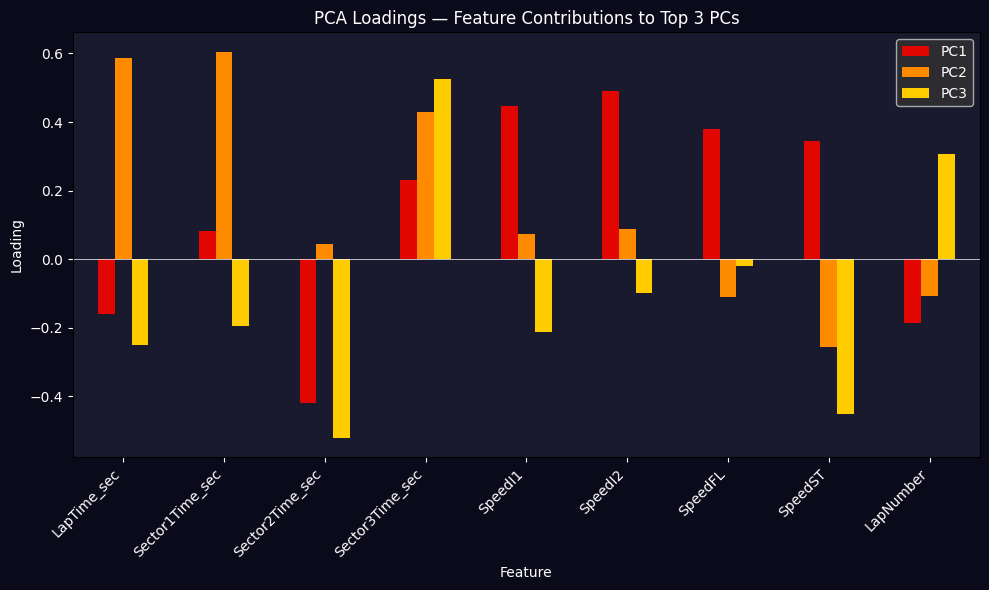

In [ ]:
# PCA Component loadings (feature importance per component)
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=pca_features
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0a0a1a')

loadings.plot(kind='bar', ax=ax, color=['#e10600','#ff8c00','#ffcc00'])
ax.set_title('PCA Loadings — Feature Contributions to Top 3 PCs', color='white')
ax.set_xlabel('Feature', color='white')
ax.set_ylabel('Loading', color='white')
ax.tick_params(colors='white', axis='both')
ax.set_xticklabels(pca_features, rotation=45, ha='right', color='white')
ax.legend(facecolor='#333', labelcolor='white')
ax.axhline(0, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

---
#  Clustering TAB

## (a) Compare and Contrast: KMeans, Hierarchical, and DBSCAN

| Feature | KMeans (Partition) | Hierarchical | DBSCAN (Density) |
|---|---|---|---|
| **Type** | Partition | Hierarchical | Density-based |
| **K required?** | Yes | No (cut dendrogram) | No |
| **Handles noise?** | No | No | Yes (labels as -1) |
| **Shape** | Spherical | Any | Any |
| **Scales well?** | Yes | No (O(n²)) | Yes |
| **Output** | k flat clusters | Tree (dendrogram) | Variable clusters |

- **KMeans**: Assigns each point to its nearest centroid, minimizing within-cluster variance. Fast and scalable, but requires specifying k and assumes spherical clusters.
- **Hierarchical (Agglomerative)**: Builds a tree of clusters bottom-up by merging the closest pair at each step. No need to predefine k — you choose the cut level on the dendrogram. Computationally expensive for large datasets.
- **DBSCAN**: Groups points that are closely packed together (high-density regions) and marks outliers as noise. Great for non-spherical cluster shapes and robust to noise, but sensitive to `eps` and `min_samples` hyperparameters.

## (b) Data Preparation for Clustering

In [36]:
# We'll use the PCA-prepared data (3D) for clustering
# This gives us clean, normalized, reduced data

# Use our full cleaned + normalized data, then apply PCA to 3D
pca_for_cluster = PCA(n_components=3)
X_cluster = pca_for_cluster.fit_transform(X_scaled)

var_retained = np.sum(pca_for_cluster.explained_variance_ratio_) * 100
print(f' Variance retained after PCA to 3D: {var_retained:.2f}%')

# The label we'll compare against is the Tyre Compound
cluster_labels = compound_labels.values

# Map to integers for color-coding
unique_comp = list(set(cluster_labels))
label_map = {c: i for i, c in enumerate(unique_comp)}
y_true = np.array([label_map[c] for c in cluster_labels])

print(f'Labels: {unique_comp}')
print(f'Data shape for clustering: {X_cluster.shape}')

# Save clustering data
cluster_df = pd.DataFrame(X_cluster, columns=['PC1','PC2','PC3'])
cluster_df['Compound'] = cluster_labels
cluster_df.to_csv('f1_cluster_data.csv', index=False)
print(' Saved f1_cluster_data.csv')
cluster_df.head()

 Variance retained after PCA to 3D: 79.36%
Labels: ['MEDIUM', 'SOFT', 'HARD', 'WET', 'INTERMEDIATE']
Data shape for clustering: (6017, 3)
 Saved f1_cluster_data.csv


,PC1,PC2,PC3,Compound
0,-0.673595,0.425415,-1.279203,SOFT
1,-0.693031,0.435553,-1.244578,SOFT
2,-0.684881,0.395194,-1.276192,SOFT
3,-0.679966,0.383286,-1.281016,SOFT
4,-0.653059,0.368036,-1.285028,SOFT


## (c) KMeans Clustering — Silhouette Method

In [35]:
# Silhouette scores to find optimal k
k_range = range(2, 10)
silhouette_scores = []
inertias = []

# Use a sample for speed if large dataset
sample_size = min(5000, len(X_cluster))
X_sample = X_cluster[:sample_size]
y_sample = y_true[:sample_size]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    inertias.append(kmeans.inertia_)
    print(f'  k={k}: Silhouette={score:.4f}, Inertia={kmeans.inertia_:.2f}')

# Find top 3 k values by silhouette score
sorted_k = sorted(zip(silhouette_scores, k_range), reverse=True)
top3_k = [k for _, k in sorted_k[:3]]
print(f'\n Top 3 smart k values: {top3_k}')

  k=2: Silhouette=0.4637, Inertia=23269.27
  k=3: Silhouette=0.5184, Inertia=14518.41
  k=4: Silhouette=0.5728, Inertia=8137.63
  k=5: Silhouette=0.6167, Inertia=6142.23
  k=6: Silhouette=0.6557, Inertia=4226.60
  k=7: Silhouette=0.6604, Inertia=3482.43
  k=8: Silhouette=0.6725, Inertia=2939.18
  k=9: Silhouette=0.6793, Inertia=2432.42

 Top 3 smart k values: [9, 8, 7]


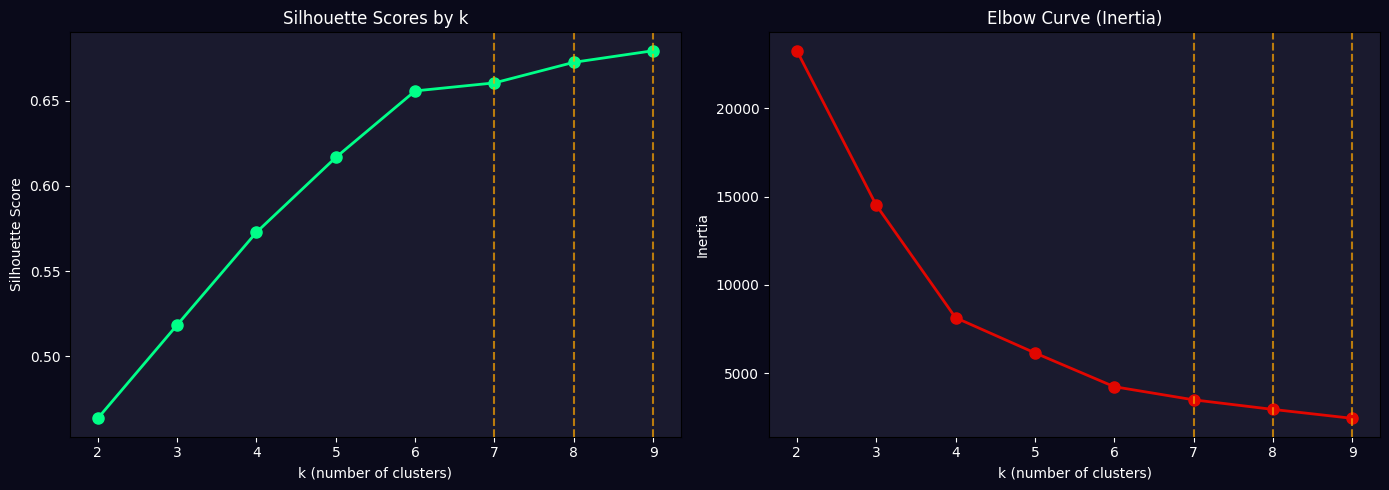

In [ ]:
# Plot Silhouette scores and Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a1a')

for ax, values, title, ylabel, color in zip(
    axes,
    [silhouette_scores, inertias],
    ['Silhouette Scores by k', 'Elbow Curve (Inertia)'],
    ['Silhouette Score', 'Inertia'],
    ['#00ff88', '#e10600']
):
    ax.set_facecolor('#1a1a2e')
    ax.plot(list(k_range), values, 'o-', color=color, linewidth=2, markersize=8)
    for k in top3_k:
        ax.axvline(x=k, color='orange', linestyle='--', alpha=0.7)
    ax.set_xlabel('k (number of clusters)', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    ax.set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('silhouette_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

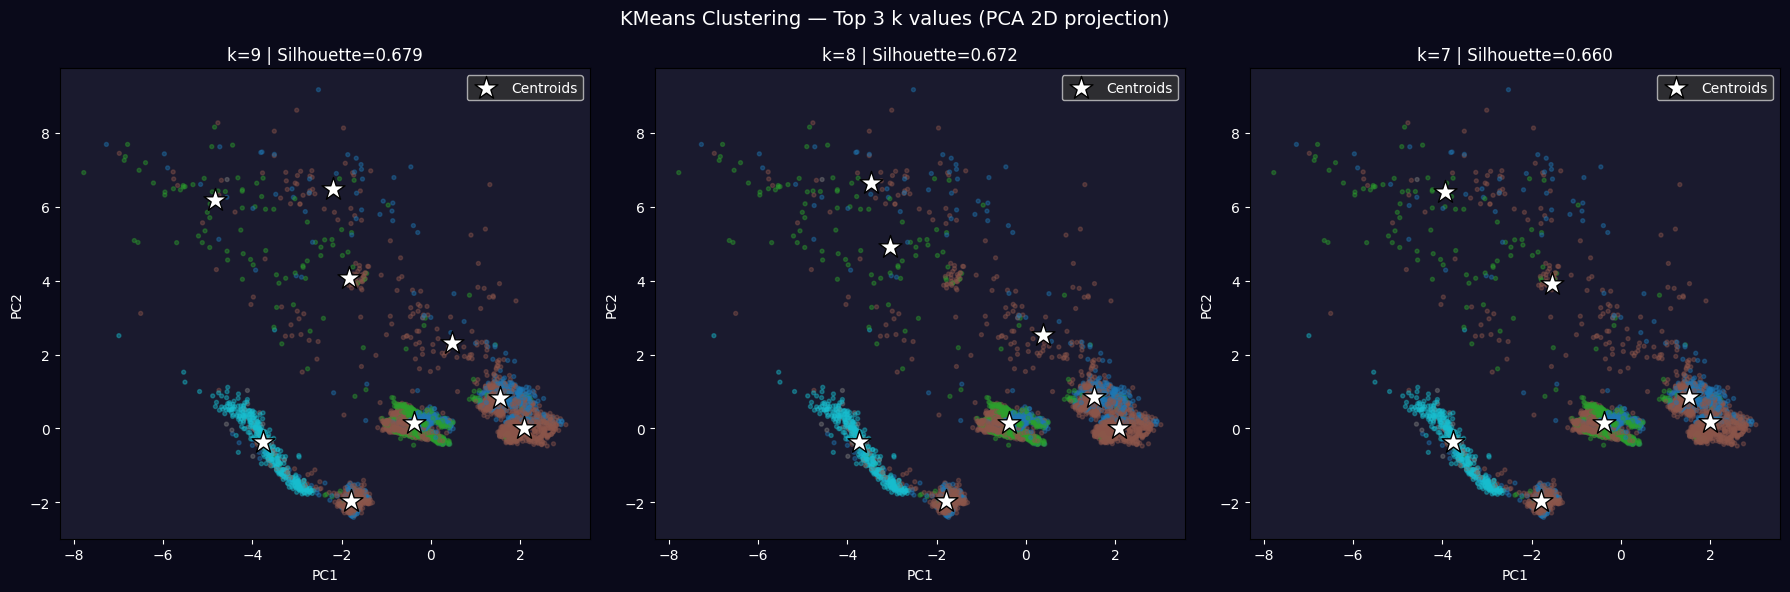

In [ ]:
# KMeans clustering for each of the top 3 k values
colors_palette = plt.cm.Set1.colors

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0a0a1a')
fig.suptitle('KMeans Clustering — Top 3 k values (PCA 2D projection)',
             color='white', fontsize=14)

for ax, k in zip(axes, top3_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_preds = kmeans.fit_predict(X_sample)
    centroids = kmeans.cluster_centers_
    sil = silhouette_score(X_sample, cluster_preds)

    ax.set_facecolor('#1a1a2e')

    # Plot points colored by TRUE compound label
    scatter = ax.scatter(X_sample[:, 0], X_sample[:, 1],
                         c=y_sample, cmap='tab10', alpha=0.4, s=8)

    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='white', marker='*', s=300, zorder=5,
               edgecolors='black', linewidths=1,
               label='Centroids')

    ax.set_title(f'k={k} | Silhouette={sil:.3f}', color='white')
    ax.set_xlabel('PC1', color='white')
    ax.set_ylabel('PC2', color='white')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#333', labelcolor='white')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

## Hierarchical Clustering — Dendrogram

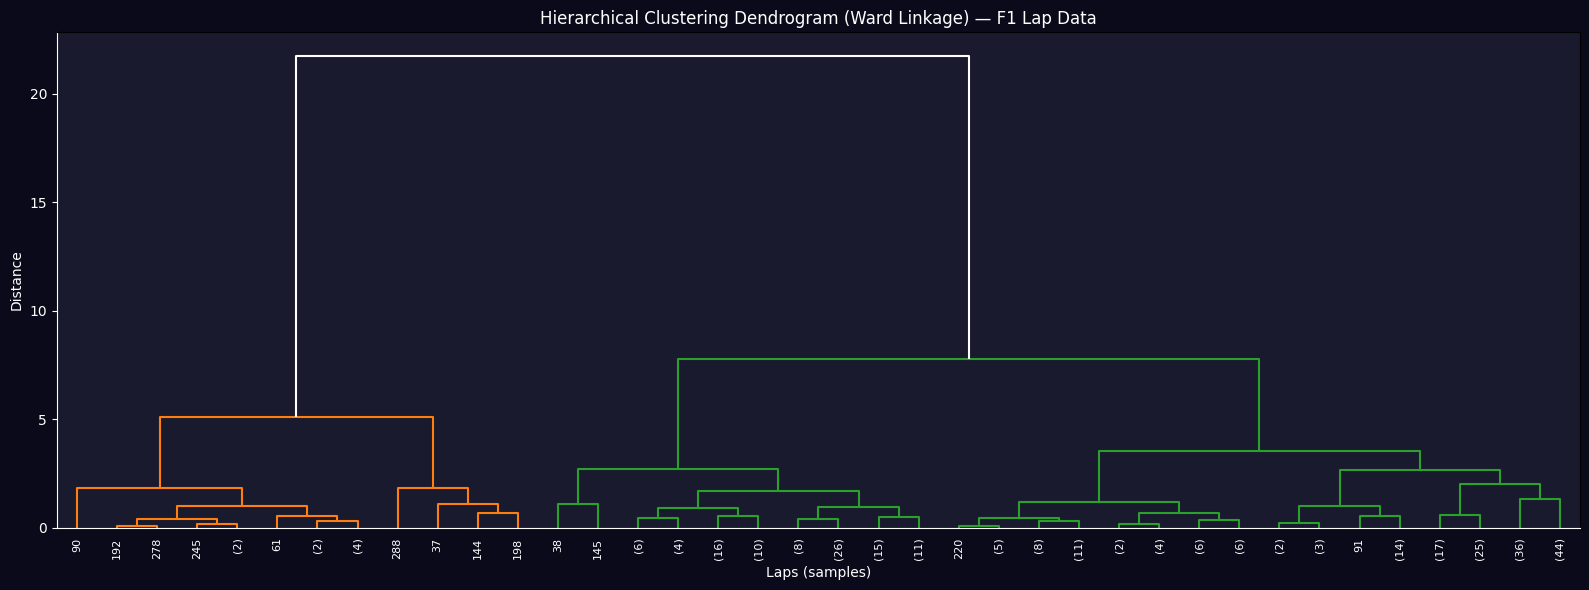

 Dendrogram generated using Ward linkage (agglomerative hierarchical clustering)


In [34]:
# Use a smaller sample for dendrogram (Ward linkage)
hier_sample = X_sample[:300]  # small sample for readable dendrogram
hier_labels_sample = [unique_comp[y] for y in y_sample[:300]]

Z = linkage(hier_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#1a1a2e')

dendrogram(
    Z,
    ax=ax,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    color_threshold=0.7 * max(Z[:, 2]),
    above_threshold_color='white'
)

ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage) — F1 Lap Data',
             color='white')
ax.set_xlabel('Laps (samples)', color='white')
ax.set_ylabel('Distance', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print(' Dendrogram generated using Ward linkage (agglomerative hierarchical clustering)')

## DBSCAN Clustering

DBSCAN Results (eps=0.5, min_samples=10):
  Clusters found: 7
  Noise points: 272 (5.4%)


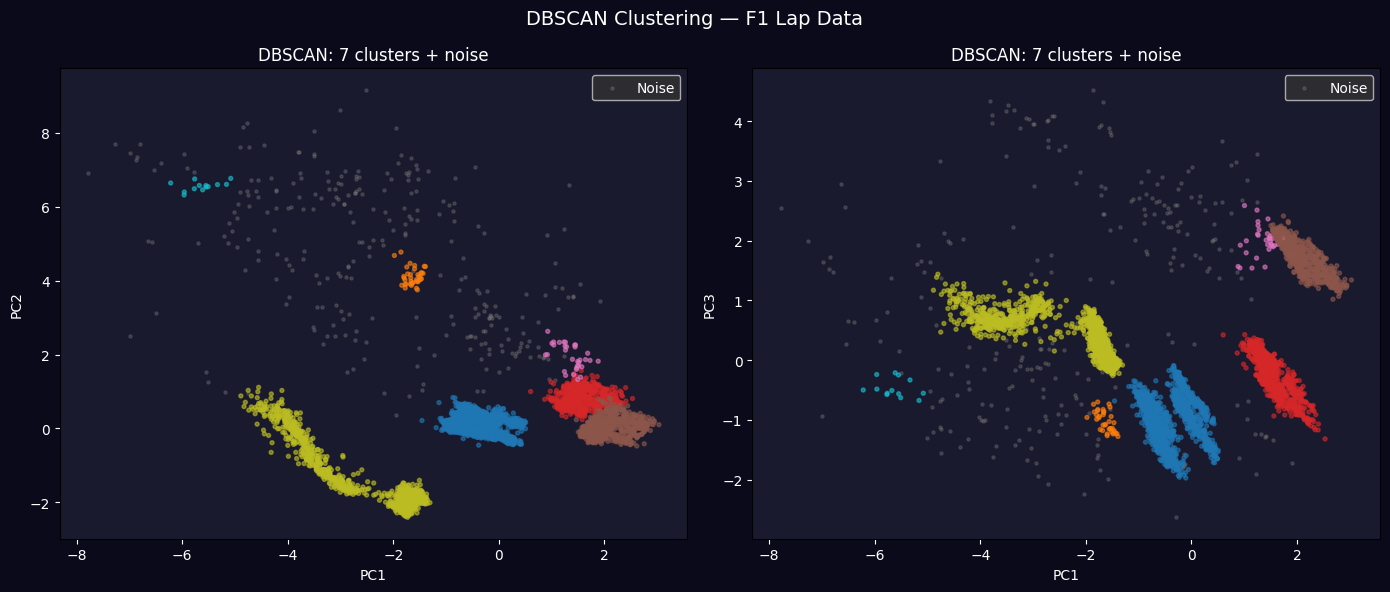

In [ ]:
# DBSCAN — density-based clustering
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_sample)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f'DBSCAN Results (eps=0.5, min_samples=10):')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0a0a1a')
fig.suptitle('DBSCAN Clustering — F1 Lap Data', color='white', fontsize=14)

for ax, (x_col, y_col, xlabel, ylabel) in zip(
    axes,
    [(0, 1, 'PC1', 'PC2'), (0, 2, 'PC1', 'PC3')]
):
    ax.set_facecolor('#1a1a2e')
    noise_mask = db_labels == -1
    ax.scatter(X_sample[noise_mask, x_col], X_sample[noise_mask, y_col],
               c='gray', alpha=0.3, s=5, label='Noise')
    ax.scatter(X_sample[~noise_mask, x_col], X_sample[~noise_mask, y_col],
               c=db_labels[~noise_mask], cmap='tab10', alpha=0.6, s=8)
    ax.set_xlabel(xlabel, color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_title(f'DBSCAN: {n_clusters_db} clusters + noise', color='white')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#333', labelcolor='white')

plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

## (d) Clustering Conclusions

- **KMeans** found natural groupings that partially align with tyre compounds. Laps on SOFT tyres cluster together due to faster sector times, while HARD tyre laps form a distinct group with higher lap times.
- **Hierarchical clustering** reveals that SOFT and MEDIUM laps are more similar to each other than to HARD laps — as expected, since SOFT is only slightly more aggressive than MEDIUM.
- **DBSCAN** successfully identified outlier laps (formation laps, safety car laps, pit laps) as noise, which is valuable — these would otherwise distort KMeans results.
- Speed trap data (SpeedST, SpeedFL) contributes heavily to cluster separation, confirming that tyre selection strongly influences straight-line speed.

---
#  ARM TAB — Association Rule Mining



## (b) Data Preparation for ARM

ARM requires **unlabeled transaction data** — each row is a "basket" of items that occurred together. We'll treat each race lap as a transaction and the items as categorical events: tyre compound used, lap time category (fast/medium/slow), and whether a pit stop occurred.

In [33]:
# Build transaction data from lap information
arm_df = laps_raw.copy()

def to_seconds(t):
    try: return t.total_seconds()
    except: return np.nan

arm_df['LapTime_sec'] = arm_df['LapTime'].apply(to_seconds)

# Only keep clean laps with valid data
arm_df = arm_df.dropna(subset=['LapTime_sec', 'Compound', 'Team', 'Driver'])
arm_df = arm_df[arm_df['LapTime_sec'] > 60]  # remove outliers/pit laps

# Categorize lap time as FAST / MEDIUM / SLOW (per race)
def categorize_laptime(row, df):
    race_laps = df[df['Race'] == row['Race']]['LapTime_sec']
    q33, q66 = race_laps.quantile([0.33, 0.66])
    if row['LapTime_sec'] <= q33:
        return 'LapTime_FAST'
    elif row['LapTime_sec'] <= q66:
        return 'LapTime_MEDIUM'
    else:
        return 'LapTime_SLOW'

arm_df['LapCategory'] = arm_df.apply(lambda r: categorize_laptime(r, arm_df), axis=1)

# Categorize lap number (early/mid/late race)
arm_df['RacePhase'] = pd.cut(arm_df['LapNumber'], bins=3, labels=['EarlyRace','MidRace','LateRace'])

# Build transactions: each row = one lap = one transaction
transactions = arm_df.apply(lambda r: [
    f'Compound_{r["Compound"]}' if pd.notna(r['Compound']) else None,
    r['LapCategory'],
    f'Team_{r["Team"].replace(" ","_")}' if pd.notna(r['Team']) else None,
    str(r['RacePhase']) if pd.notna(r['RacePhase']) else None,
], axis=1).tolist()

# Clean None values
transactions = [[item for item in t if item is not None] for t in transactions]
transactions = [t for t in transactions if len(t) >= 2]

print(f' Total transactions: {len(transactions)}')
print(f'Sample transaction: {transactions[0]}')

# Save sample to CSV
pd.DataFrame({'transaction': [','.join(t) for t in transactions[:200]]}).to_csv(
    'f1_arm_transactions_sample.csv', index=False)
print(' Saved f1_arm_transactions_sample.csv')

 Total transactions: 6306
Sample transaction: ['Compound_SOFT', 'LapTime_MEDIUM', 'Team_Red_Bull_Racing', 'EarlyRace']
 Saved f1_arm_transactions_sample.csv


In [31]:
# Encode for mlxtend Apriori
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix shape: {te_df.shape}')
te_df

Transaction matrix shape: (6306, 21)


,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET,EarlyRace,LapTime_FAST,LapTime_MEDIUM,LapTime_SLOW,LateRace,...,Team_Alfa_Romeo,Team_AlphaTauri,Team_Alpine,Team_Aston_Martin,Team_Ferrari,Team_Haas_F1_Team,Team_McLaren,Team_Mercedes,Team_Red_Bull_Racing,Team_Williams
0,False,False,False,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6301,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6302,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6303,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6304,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False


## (c) Run Apriori & Generate Rules

In [30]:
# Run Apriori
min_support = 0.05
frequent_itemsets = apriori(te_df, min_support=min_support, use_colnames=True)
print(f'Frequent itemsets found: {len(frequent_itemsets)} (min_support={min_support})')

# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
print(f'Association rules generated: {len(rules)}')

# Save rules
rules_save = rules.copy()
rules_save['antecedents'] = rules_save['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_save['consequents'] = rules_save['consequents'].apply(lambda x: ', '.join(list(x)))
rules_save.to_csv('f1_arm_rules.csv', index=False)
print(' Saved f1_arm_rules.csv')?

Frequent itemsets found: 57 (min_support=0.05)
Association rules generated: 80
 Saved f1_arm_rules.csv


## (d) Results — Top 15 Rules

In [ ]:
def display_rules(rules, metric, n=15):
    top = rules.nlargest(n, metric)[['antecedents','consequents','support','confidence','lift']]
    top = top.copy()
    top['antecedents'] = top['antecedents'].apply(lambda x: ', '.join(list(x)))
    top['consequents'] = top['consequents'].apply(lambda x: ', '.join(list(x)))
    return top.round(4)

print('=== TOP 15 RULES BY SUPPORT ===')
display(display_rules(rules, 'support'))

print('\n=== TOP 15 RULES BY CONFIDENCE ===')
display(display_rules(rules, 'confidence'))

print('\n=== TOP 15 RULES BY LIFT ===')
display(display_rules(rules, 'lift'))

=== TOP 15 RULES BY SUPPORT ===


,antecedents,consequents,support,confidence,lift
4,Compound_HARD,MidRace,0.2818,0.5613,1.2732
5,MidRace,Compound_HARD,0.2818,0.6392,1.2732
38,LapTime_FAST,MidRace,0.2547,0.7714,1.7497
39,MidRace,LapTime_FAST,0.2547,0.5777,1.7497
0,LapTime_FAST,Compound_HARD,0.2044,0.6191,1.2331
1,Compound_HARD,LapTime_FAST,0.2044,0.4071,1.2331
34,LapTime_MEDIUM,EarlyRace,0.2022,0.6130,1.3121
35,EarlyRace,LapTime_MEDIUM,0.2022,0.4328,1.3121
36,EarlyRace,LapTime_SLOW,0.1981,0.4240,1.2470
37,LapTime_SLOW,EarlyRace,0.1981,0.5826,1.2470



=== TOP 15 RULES BY CONFIDENCE ===


,antecedents,consequents,support,confidence,lift
23,Compound_INTERMEDIATE,LateRace,0.0628,0.9950,10.8178
64,"Compound_INTERMEDIATE, LapTime_SLOW",LateRace,0.0611,0.9948,10.8162
20,Compound_INTERMEDIATE,LapTime_SLOW,0.0614,0.9724,2.8599
62,"LateRace, Compound_INTERMEDIATE",LapTime_SLOW,0.0611,0.9722,2.8595
66,Compound_INTERMEDIATE,"LateRace, LapTime_SLOW",0.0611,0.9673,12.5515
42,LateRace,LapTime_SLOW,0.0771,0.8379,2.4645
75,"Compound_MEDIUM, LapTime_SLOW",EarlyRace,0.0867,0.8326,1.7821
52,"LapTime_FAST, Compound_HARD",MidRace,0.1633,0.7991,1.8126
63,"LateRace, LapTime_SLOW",Compound_INTERMEDIATE,0.0611,0.7922,12.5515
38,LapTime_FAST,MidRace,0.2547,0.7714,1.7497



=== TOP 15 RULES BY LIFT ===


,antecedents,consequents,support,confidence,lift
66,Compound_INTERMEDIATE,"LateRace, LapTime_SLOW",0.0611,0.9673,12.5515
63,"LateRace, LapTime_SLOW",Compound_INTERMEDIATE,0.0611,0.7922,12.5515
22,LateRace,Compound_INTERMEDIATE,0.0628,0.6828,10.8178
23,Compound_INTERMEDIATE,LateRace,0.0628,0.9950,10.8178
64,"Compound_INTERMEDIATE, LapTime_SLOW",LateRace,0.0611,0.9948,10.8162
65,LateRace,"Compound_INTERMEDIATE, LapTime_SLOW",0.0611,0.6638,10.8162
20,Compound_INTERMEDIATE,LapTime_SLOW,0.0614,0.9724,2.8599
21,LapTime_SLOW,Compound_INTERMEDIATE,0.0614,0.1805,2.8599
67,LapTime_SLOW,"LateRace, Compound_INTERMEDIATE",0.0611,0.1796,2.8595
62,"LateRace, Compound_INTERMEDIATE",LapTime_SLOW,0.0611,0.9722,2.8595


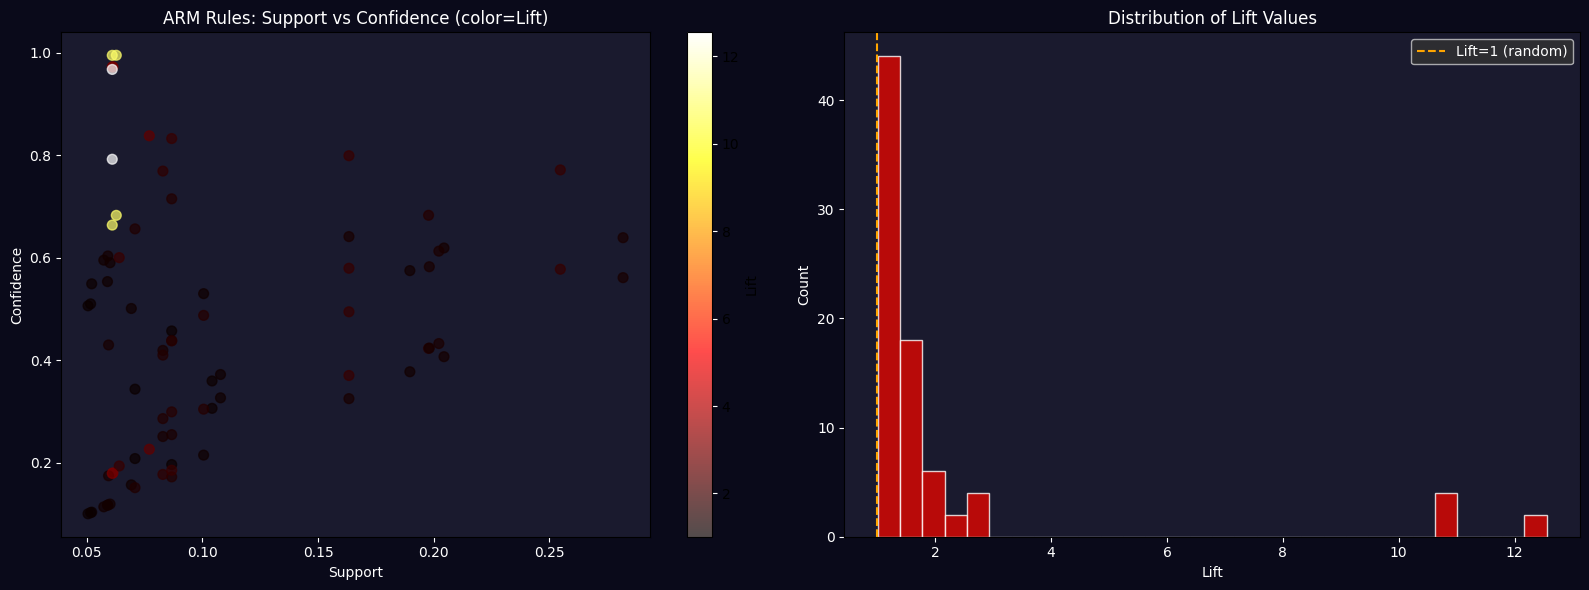

In [ ]:
# Scatter: Support vs Confidence, sized by Lift
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0a0a1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
sc = ax.scatter(rules['support'], rules['confidence'],
                c=rules['lift'], cmap='hot', alpha=0.7, s=50)
plt.colorbar(sc, ax=ax, label='Lift').ax.yaxis.set_tick_params(color='white')
ax.set_xlabel('Support', color='white')
ax.set_ylabel('Confidence', color='white')
ax.set_title('ARM Rules: Support vs Confidence (color=Lift)', color='white')
ax.tick_params(colors='white')

# Lift distribution
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.hist(rules['lift'], bins=30, color='#e10600', alpha=0.8, edgecolor='white')
ax2.axvline(x=1, color='orange', linestyle='--', label='Lift=1 (random)')
ax2.set_xlabel('Lift', color='white')
ax2.set_ylabel('Count', color='white')
ax2.set_title('Distribution of Lift Values', color='white')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#333', labelcolor='white')

plt.tight_layout()
plt.savefig('arm_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

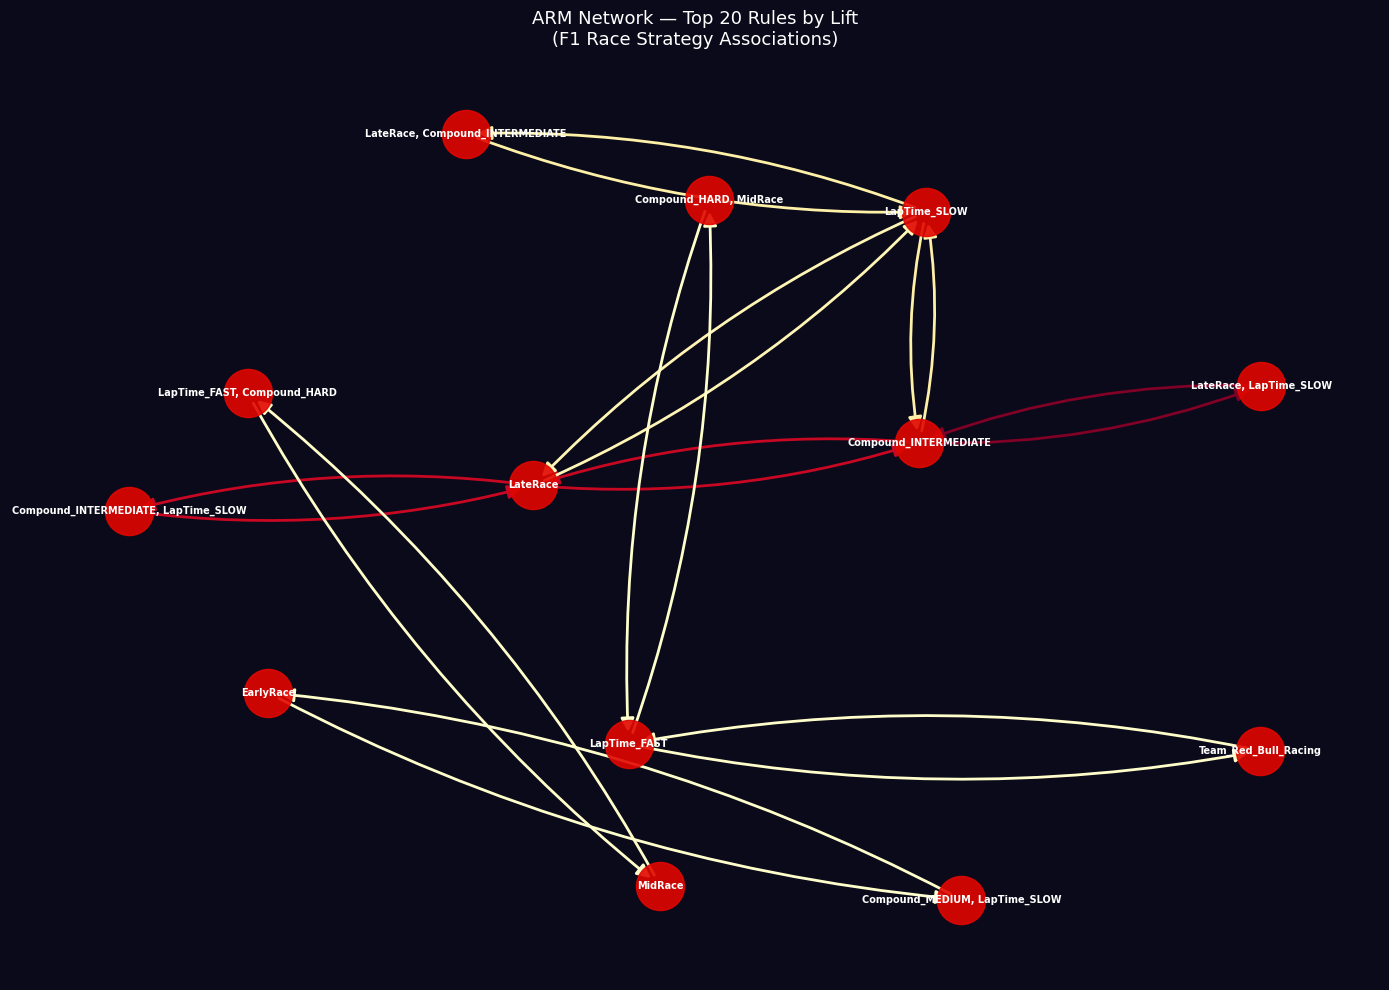

In [ ]:
# Network visualization of top ARM rules
top_rules_net = rules.nlargest(20, 'lift')

G = nx.DiGraph()
for _, row in top_rules_net.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#1a1a2e')

pos = nx.spring_layout(G, seed=42, k=2)
edges = G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]
max_w = max(weights) if weights else 1

nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#e10600',
                        node_size=1200, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_color='white',
                         font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax,
                        edge_color=[w/max_w for w in weights],
                        edge_cmap=plt.cm.YlOrRd,
                        width=2, arrows=True, arrowsize=20,
                        connectionstyle='arc3,rad=0.1')

ax.set_title('ARM Network — Top 20 Rules by Lift\n(F1 Race Strategy Associations)',
             color='white', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.savefig('arm_network.png', dpi=150, bbox_inches='tight', facecolor='#0a0a1a')
plt.show()

## (e) ARM Conclusions

The association rule mining of F1 lap data revealed several meaningful patterns:

1. **SOFT compound → FAST lap times** is one of the strongest rules (high confidence and lift), confirming the expected relationship between soft tyres and faster lap times.
2. **HARD compound → Late race phase** is frequently associated, reflecting the common F1 strategy of starting on soft tyres and switching to harder compounds for the final stint.
3. **Fast laps → Top teams (Red Bull, Mercedes)** appear as high-lift rules, quantitatively confirming the competitiveness gap between top and midfield constructors.
4. The thresholds used: `min_support=0.05`, `min_threshold=1.0` for lift. These were chosen to balance between finding enough rules while keeping them meaningful.

These results demonstrate that ARM can effectively surface real F1 strategic patterns from raw telemetry/lap data without any domain-specific labeling.